### interpretation of the whole notebook results and summary of key findings:
- Temporal patterns: We see clear rush hour peaks on weekdays, with a smaller midday peak. Weekends have a more even distribution but still show higher usage during the day.
- Geographic analysis: Certain stations and districts are much more popular, likely due to proximity to transit hubs, commercial areas, or tourist attractions. There are also strong intra-district flows in some areas, while others have more inter-district trips.
- Station network: A few stations act as major hubs with many unique destinations, while most stations have a more limited set of routes. Some popular routes are likely influenced by nearby attractions or transit connections.
- Trip duration: The distribution is heavily skewed with a long tail of very long trips. The median is much lower than the mean, indicating many short trips and a few very long ones. Outliers are present but not dominant.
- Short trips: A significant portion of trips are under 2 minutes, with many being same-station returns. This could indicate quick returns or potential data issues (e.g., accidental check-ins).
- Long trips: There are also trips over 12 hours, which may indicate lost bikes, rentals that span multiple days, or data errors. These long trips are relatively rare but can significantly affect average duration statistics.    
- Station-specific analysis: For a station like "cyclo", we can see its specific usage patterns, popular routes, and duration characteristics. This can help identify if it's primarily a starting point, an endpoint, or both, and how it fits into the overall network.
Overall, the analysis provides a comprehensive view of the BIXI bike-share system, highlighting key trends, popular stations and routes, and areas for potential improvement (e.g., addressing short trip patterns
or investigating long trip outliers). The insights can inform operational decisions, marketing strategies, and future data collection efforts."""

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ All libraries loaded successfully!")
print(f"DuckDB version: {duckdb.__version__}")

✓ All libraries loaded successfully!
DuckDB version: 1.4.4


In [5]:
!pwd

/Users/user/Downloads/MTECH2526/EBA5006_project/bixi-analytics/EDA


## Descriptive EDA (first layer)

BIXI Analysis Script
Data path: ../../data/**/*.parquet
Output directory: analysis_output

TEMPORAL ANALYSIS


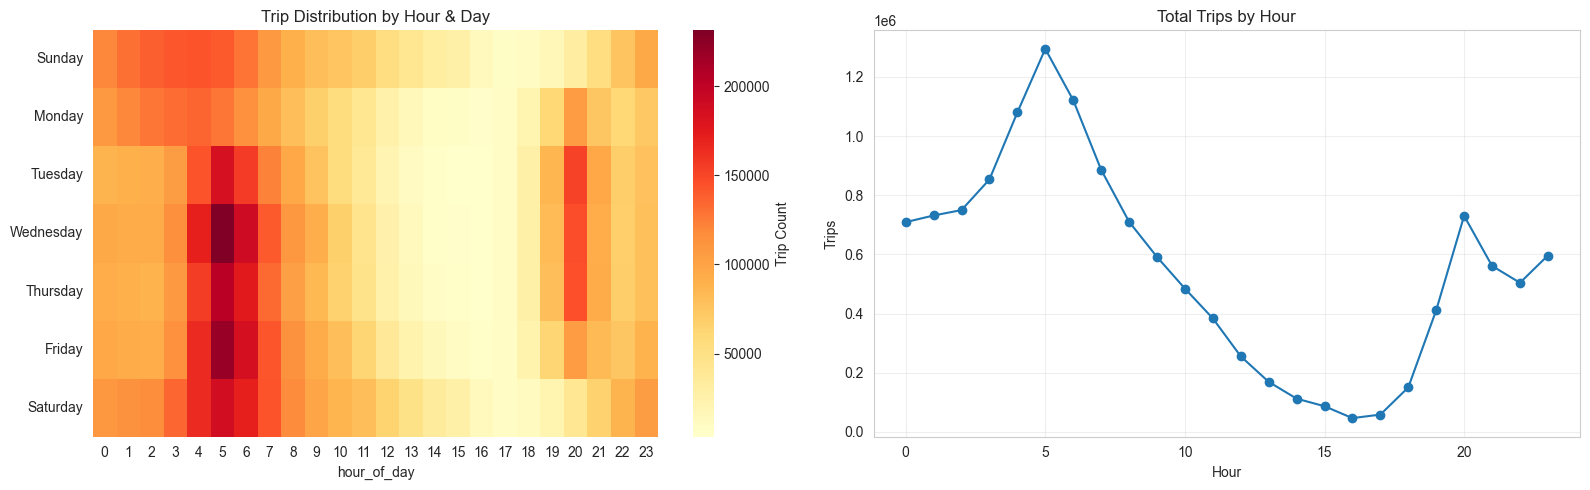


BUSIEST TIMES (top 15):
Wednesday  05:00 -  231,172 trips (avg 16.3 min)
Friday     05:00 -  219,343 trips (avg 16.0 min)
Thursday   05:00 -  202,840 trips (avg 17.0 min)
Wednesday  06:00 -  190,737 trips (avg 16.6 min)
Saturday   05:00 -  188,390 trips (avg 16.9 min)
Friday     06:00 -  185,189 trips (avg 17.9 min)
Tuesday    05:00 -  184,105 trips (avg 16.8 min)
Thursday   06:00 -  174,806 trips (avg 15.9 min)
Saturday   06:00 -  171,473 trips (avg 17.7 min)
Wednesday  04:00 -  171,289 trips (avg 15.7 min)
Saturday   04:00 -  164,910 trips (avg 16.5 min)
Friday     04:00 -  164,540 trips (avg 16.1 min)
Tuesday    06:00 -  155,648 trips (avg 15.7 min)
Thursday   04:00 -  155,360 trips (avg 15.2 min)
Tuesday    20:00 -  152,586 trips (avg 15.3 min)

SLOWEST TIMES (bottom 10):
Tuesday    16:00 -    3,513 trips
Wednesday  16:00 -    3,626 trips
Thursday   16:00 -    4,225 trips
Tuesday    15:00 -    4,321 trips
Monday     16:00 -    4,469 trips
Wednesday  15:00 -    4,804 trips
Friday  

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


TOP 50 ROUTES:
Parc Jean-Drapeau (Chemin Macdonald) → Parc Jean-Drapeau (Chemin Macdonald)  12410 trips (avg  37.4 min)
Métro Mont-Royal (Utilités publiques / Rivard) → Marquette / du Mont-Royal             5058 trips (avg   7.0 min)
Marquette / du Mont-Royal           → Métro Mont-Royal (Utilités publiques / Rivard)   4711 trips (avg  10.8 min)
Métro Pie-IX (Pierre-de-Coubertin / Desjardins) → Desjardins / Ontario                  4597 trips (avg   4.9 min)
Berri / Cherrier                    → Émile-Duployé / Sherbrooke            4468 trips (avg   5.9 min)
Ste-Catherine / St-Laurent          → Ste-Catherine / St-Laurent            4297 trips (avg  19.2 min)
Métro Joliette  (Hochelaga / Joliette) → Aylwin / Ontario                      4217 trips (avg   4.0 min)
du Canal / McLaughlin               → du Canal / McLaughlin                 4186 trips (avg  25.6 min)
de la Commune / Place Jacques-Cartier → de la Commune / Place Jacques-Cartier   4037 trips (avg  29.4 min)
Desjardins / O

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


MOST CONNECTED STATIONS (HUBS):
du Mont-Royal / Clark                107,638 trips → 904 destinations (avg  13.8 min) [Le Plateau-Mont-Royal]
des Pins / St-Laurent                 79,154 trips → 893 destinations (avg  15.0 min) [Le Plateau-Mont-Royal]
Métro Mont-Royal (Utilités publiques / Rivard)  117,746 trips → 883 destinations (avg  12.5 min) [Le Plateau-Mont-Royal]
Parc Jeanne-Mance (monument sir George-Étienne-Cartier)   48,003 trips → 878 destinations (avg  17.6 min) [Le Plateau-Mont-Royal]
de la Commune / Place Jacques-Cartier   52,799 trips → 877 destinations (avg  29.0 min) [Ville-Marie]
Laurier / St-Denis                    84,152 trips → 869 destinations (avg  11.9 min) [Le Plateau-Mont-Royal]
Berri / Rachel                        56,632 trips → 865 destinations (avg  16.1 min) [Le Plateau-Mont-Royal]
Clark / Laurier                       46,617 trips → 861 destinations (avg  12.8 min) [Le Plateau-Mont-Royal]
St-Dominique / Laurier                44,510 trips → 860 destina

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


DURATION STATISTICS (minutes):
       min =       0.00 min (          13 ms)
       max =  255388.92 min (15,323,335,058 ms)
      mean =      16.84 min (   1,010,443 ms)
    median =      10.35 min (     620,887 ms)
        q1 =       5.97 min (     358,149 ms)
        q3 =      17.62 min (   1,057,066 ms)
       p95 =      35.55 min (   2,133,271 ms)
       p99 =      60.73 min (   3,643,916 ms)


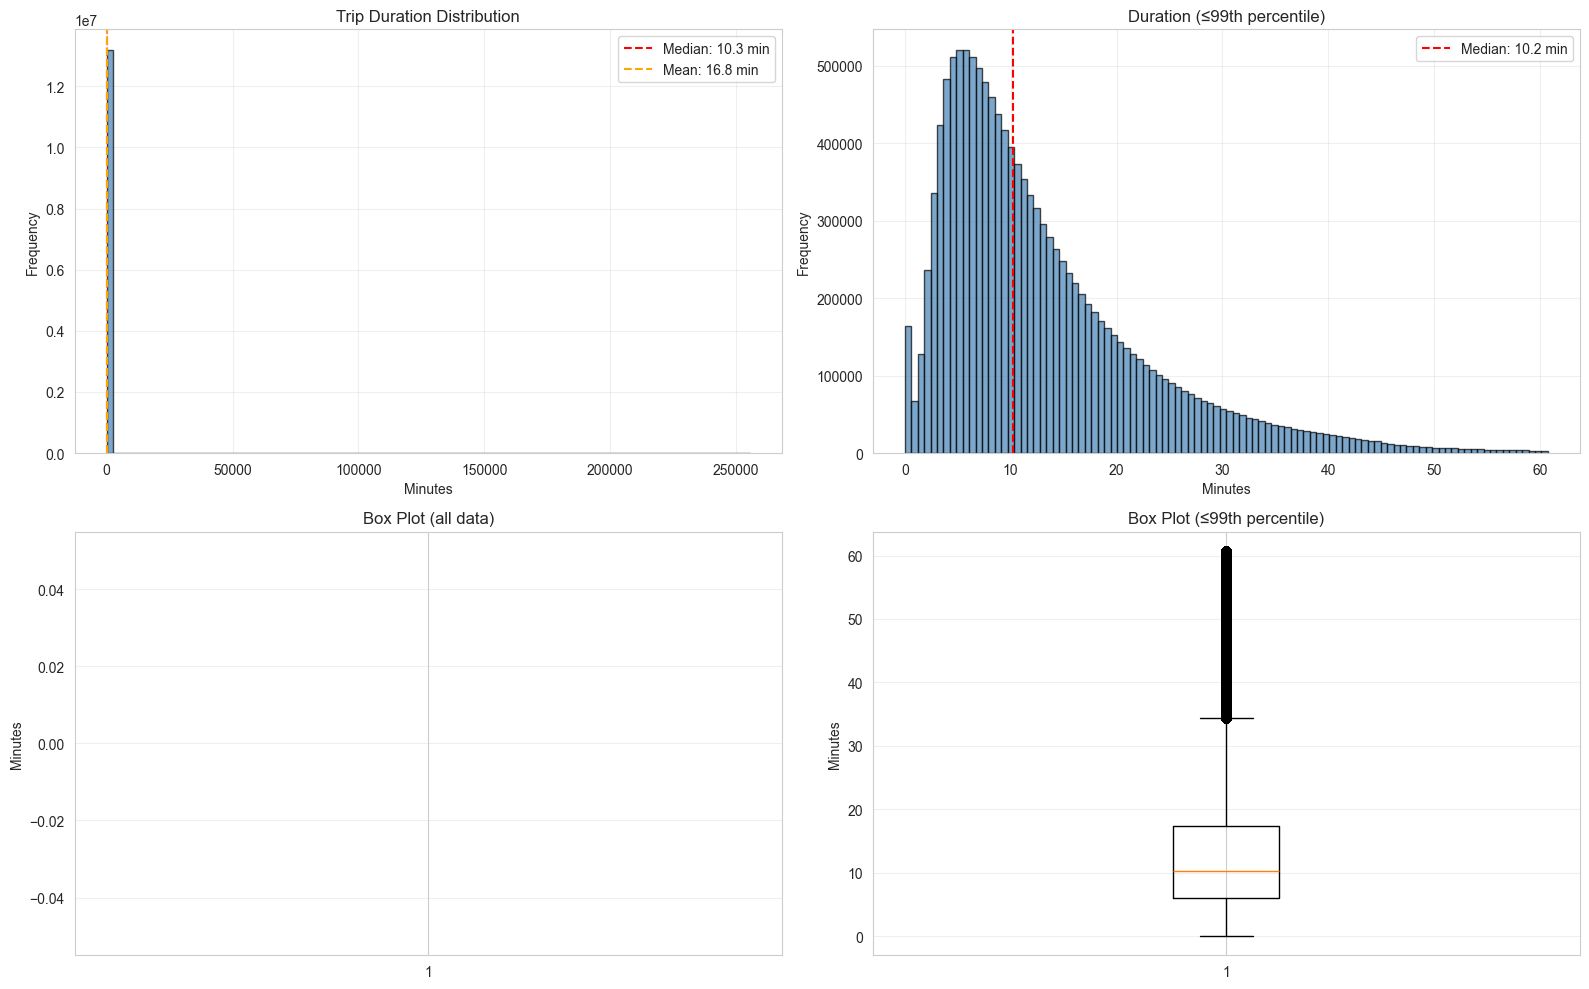


OUTLIERS (IQR method): 687,237 trips (5.18%)
Lower bound: -11.50 min, Upper bound: 35.09 min

SHORT TRIP ANALYSIS (< 2 minutes)

Total short trips: 416,873
Same station returns: 238,943 (57.3%)
Different station:    177,930 (42.7%)

TOP 30 SHORT ROUTES:
Same Station           27.9s avg |  2346 trips | St-Patrick / Thomas-Keefer
Same Station           28.3s avg |  2331 trips | Complexe Desjardins (St-Urbain
Same Station           29.8s avg |  2093 trips | Métro St-Laurent (de Maisonneu
Same Station           29.0s avg |  2040 trips | Clark / Laurier
Same Station           28.9s avg |  1964 trips | Gilford / St-Denis
Same Station           28.0s avg |  1889 trips | Parc Jeanne-Mance (du Mont-Roy
Same Station           28.7s avg |  1659 trips | Roy / Saint-Laurent
Same Station           27.8s avg |  1624 trips | Mackay / René-Lévesque
Same Station           31.5s avg |  1528 trips | Square Viger (Berri / Viger)
Same Station           27.6s avg |  1505 trips | Charles-Biddle / Atwater
Sam

/var/folders/g1/d5m_mwrs139bdddffgxlr6kr0000gn/T/ipykernel_12806/3037262330.py:382: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([same_data, diff_data], labels=['Same','Different'], patch_artist=True)


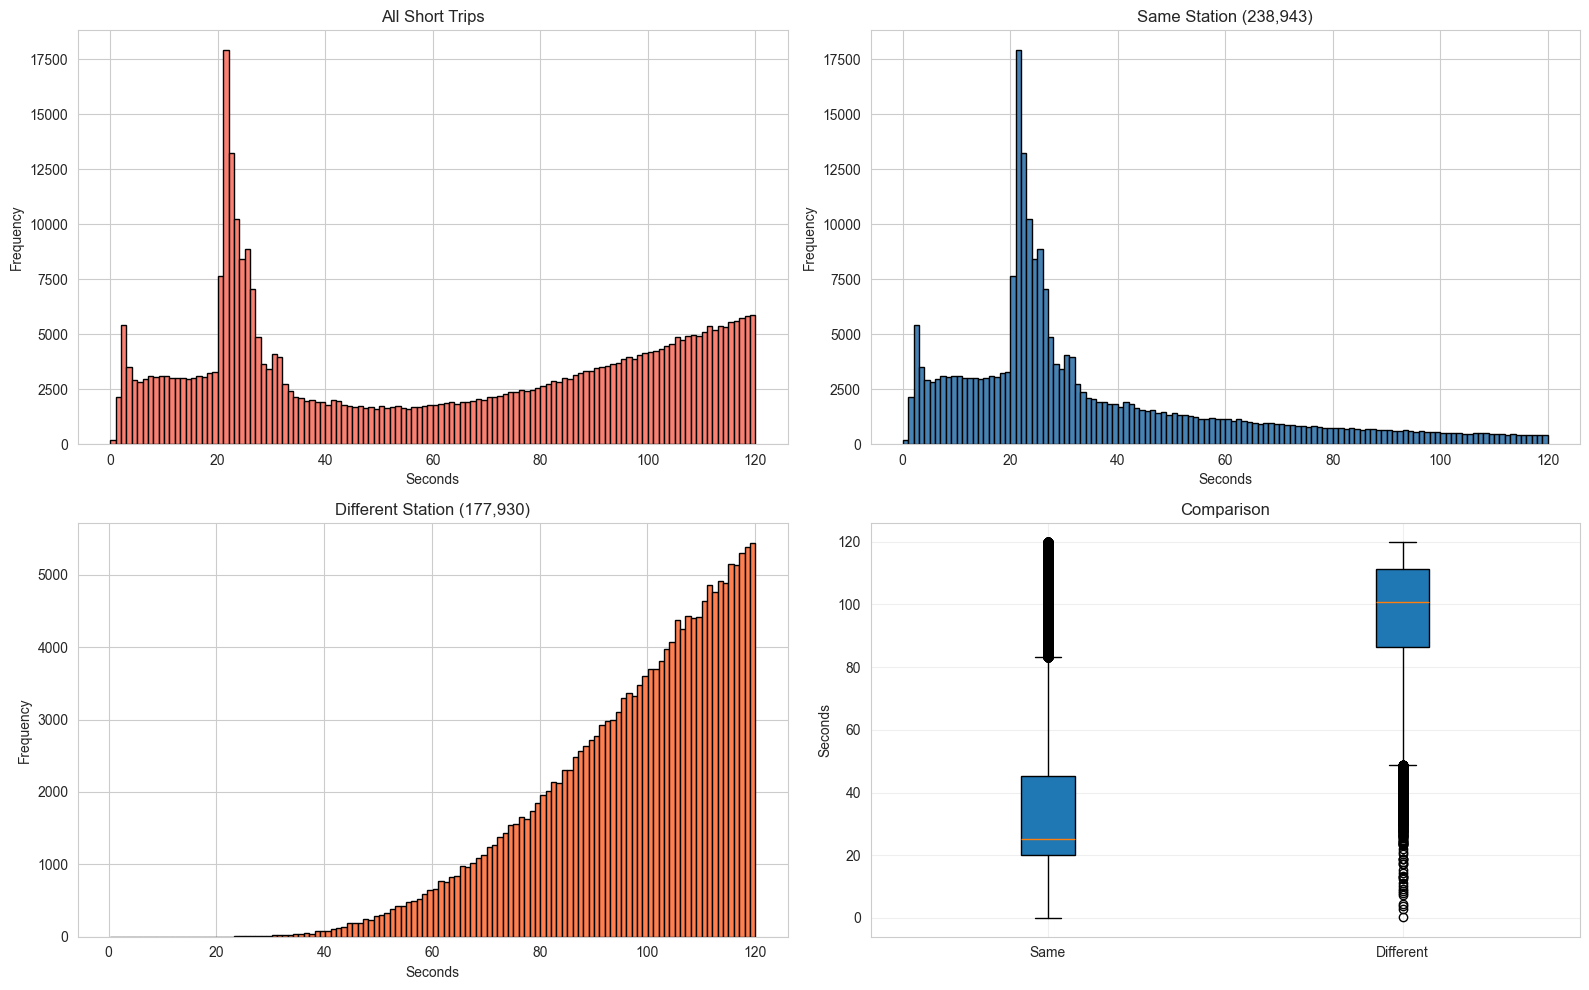


LONG TRIP ANALYSIS (> 12 hours)

Total long trips: 8,335
Same station returns: 516 (6.2%)
Different station:    7,819 (93.8%)

TOP 30 LONG ROUTES:
Different Station     150.8h avg |     7 trips | Métro Papineau (Dorion / De Ma
      → cyclo
Different Station      34.4h avg |     7 trips | Métro Jarry (Lajeunesse / Jarr
      → Rousselot / Jarry
Same Station           23.0h avg |     6 trips | Métro Crémazie (Crémazie / Laj
Same Station           43.5h avg |     6 trips | Churchill / Empire
Different Station     653.3h avg |     6 trips | Métro Henri-Bourassa (Henri-Bo
      → cyclo
Same Station           31.4h avg |     6 trips | Stinson / Montpellier
Different Station      50.6h avg |     6 trips | de la Commune / King
      → cyclo
Different Station      27.6h avg |     6 trips | de la Commune / Place Jacques-
      → cyclo
Same Station           15.3h avg |     5 trips | Champdoré / de Lorimier
Same Station           16.9h avg |     5 trips | du Canal / McLaughlin
Different Station

/var/folders/g1/d5m_mwrs139bdddffgxlr6kr0000gn/T/ipykernel_12806/3037262330.py:466: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


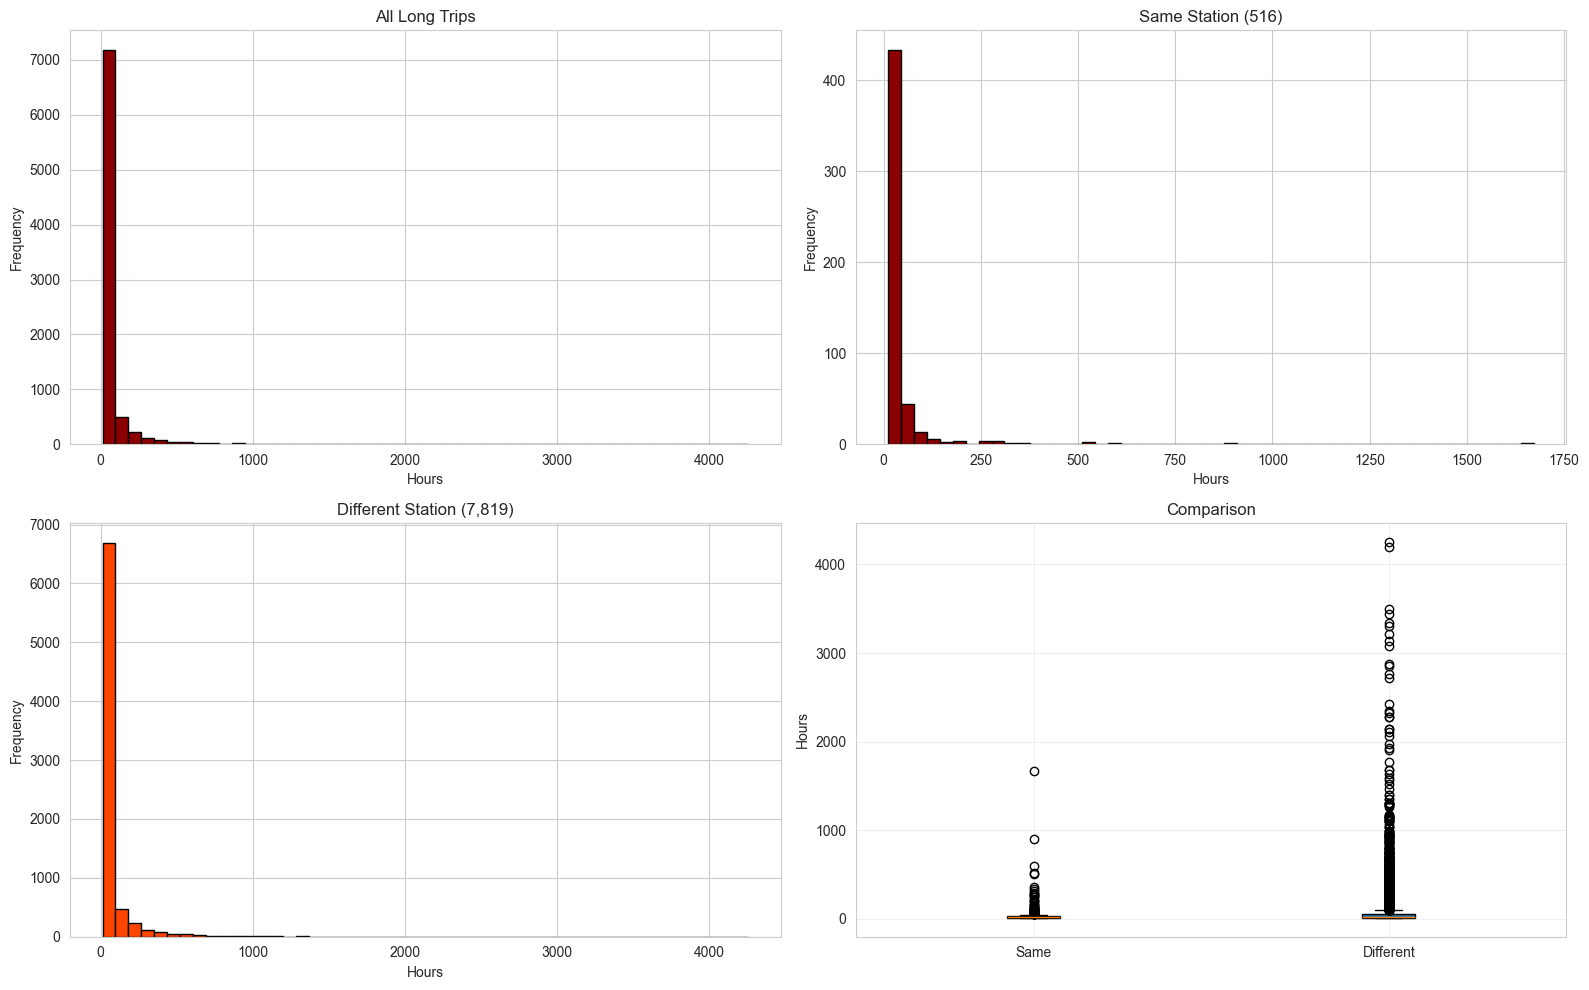


STATION-SPECIFIC ANALYSIS: 'cyclo'

Basic stats:
   total_trips  trips_from  trips_to
0         1623          10      1622

Top routes FROM station:
         end_station_name                   end_station_district  cnt  \
0                   cyclo                                   None    9   
1  Wilderton  / Van Horne  Côte-des-Neiges - Notre-Dame-de-Grâce    1   

         avg_ms   median_ms  
0  4.127878e+04     11830.0  
1  3.426579e+07  34265792.0  

Top routes TO station:
                                   start_station_name  \
0      Métro Henri-Bourassa (Henri-Bourassa / Millen)   
1                                  Laurier / St-Denis   
2            Métro Papineau (Dorion / De Maisonneuve)   
3                                  Marmier / St-Denis   
4                                 de Gaspé / de Liège   
5     Complexe Desjardins (St-Urbain / René-Lévesque)   
6                                de la Commune / King   
7                                               cyclo   
8  

/var/folders/g1/d5m_mwrs139bdddffgxlr6kr0000gn/T/ipykernel_12806/3037262330.py:578: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_from, data_to], labels=['FROM','TO'], patch_artist=True)


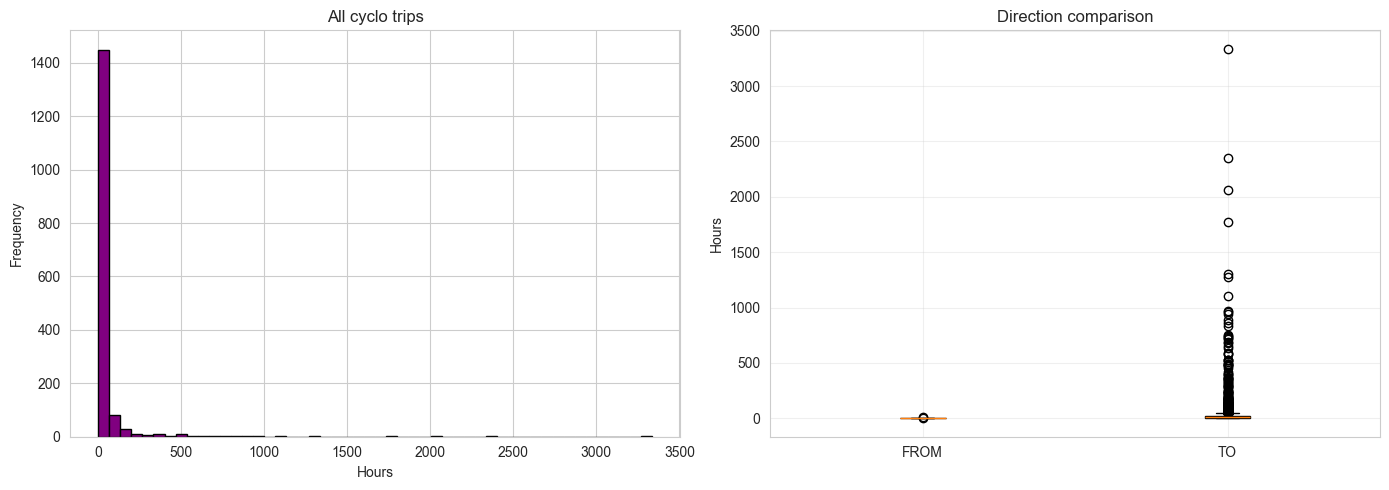


All analyses completed. Results and plots saved in analysis_output


In [6]:
#!/usr/bin/env python3
"""
BIXI Bike-Share Analysis Script
Based on the DuckDB-heavy analysis notebook.
This script reads all Parquet files from a data directory and produces:
- Temporal distributions (hour/day patterns)
- Geographic analysis (top stations, district flows)
- Station network analysis (popular routes, hubs)
- Trip duration analysis (statistics, outliers, short/long trips)
- Optional: station-specific deep dive (e.g., "cyclo")
"""

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# =============================================================================
# CONFIGURATION
# =============================================================================
DATA_PATH = "../../data/**/*.parquet"          # Path to your parquet files
OUTPUT_DIR = "analysis_output"           # Directory to save plots and CSV
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def run_query(query, as_df=True):
    """Run a DuckDB query and return a DataFrame or connection result."""
    conn = duckdb.connect()
    result = conn.execute(query)
    if as_df:
        return result.df()
    else:
        return result.fetchall()

# =============================================================================
# 1. TEMPORAL ANALYSIS
# =============================================================================
def temporal_analysis():
    print("\n" + "="*80)
    print("TEMPORAL ANALYSIS")
    print("="*80)

    # Hourly distribution by day of week
    query = """
        SELECT
            HOUR(to_timestamp(start_time_ms/1000.0)) as hour_of_day,
            DAYOFWEEK(to_timestamp(start_time_ms/1000.0)) as day_of_week,
            COUNT(*) as trip_count,
            AVG(end_time_ms - start_time_ms) as avg_duration_ms
        FROM read_parquet('{}')
        GROUP BY hour_of_day, day_of_week
        ORDER BY hour_of_day, day_of_week
    """.format(DATA_PATH)
    df_temporal = run_query(query)

    # Map day numbers to names
    day_names = {0:'Sunday',1:'Monday',2:'Tuesday',3:'Wednesday',
                 4:'Thursday',5:'Friday',6:'Saturday'}
    df_temporal['day_name'] = df_temporal['day_of_week'].map(day_names)

    # Heatmap
    pivot = df_temporal.pivot_table(index='day_of_week', columns='hour_of_day',
                                     values='trip_count', fill_value=0)
    pivot.index = [day_names[i] for i in pivot.index]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,5))
    sns.heatmap(pivot, cmap='YlOrRd', ax=ax1, cbar_kws={'label':'Trip Count'})
    ax1.set_title('Trip Distribution by Hour & Day')

    hourly = df_temporal.groupby('hour_of_day')['trip_count'].sum().reset_index()
    ax2.plot(hourly['hour_of_day'], hourly['trip_count'], marker='o')
    ax2.set_title('Total Trips by Hour')
    ax2.set_xlabel('Hour')
    ax2.set_ylabel('Trips')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'temporal_heatmap.png'), dpi=150)
    plt.show()

    # Busiest/slowest times
    print("\nBUSIEST TIMES (top 15):")
    busiest = df_temporal.nlargest(15, 'trip_count')[['hour_of_day','day_name','trip_count','avg_duration_ms']]
    for _, row in busiest.iterrows():
        avg_min = row['avg_duration_ms']/60000
        print(f"{row['day_name']:10} {int(row['hour_of_day']):02d}:00 - {row['trip_count']:>8,} trips (avg {avg_min:.1f} min)")

    print("\nSLOWEST TIMES (bottom 10):")
    slowest = df_temporal.nsmallest(10, 'trip_count')[['hour_of_day','day_name','trip_count']]
    for _, row in slowest.iterrows():
        print(f"{row['day_name']:10} {int(row['hour_of_day']):02d}:00 - {row['trip_count']:>8,} trips")

    return df_temporal

# =============================================================================
# 2. GEOGRAPHIC ANALYSIS
# =============================================================================
def geographic_analysis():
    print("\n" + "="*80)
    print("GEOGRAPHIC ANALYSIS")
    print("="*80)

    # Top start stations
    query_top_start = """
        SELECT start_station_name, start_station_district, COUNT(*) as cnt
        FROM read_parquet('{}')
        GROUP BY start_station_name, start_station_district
        ORDER BY cnt DESC LIMIT 30
    """.format(DATA_PATH)
    df_top_start = run_query(query_top_start)
    print("\nTOP 30 START STATIONS:")
    print(df_top_start.to_string(index=False))

    # Top end stations
    query_top_end = """
        SELECT end_station_name, end_station_district, COUNT(*) as cnt
        FROM read_parquet('{}')
        GROUP BY end_station_name, end_station_district
        ORDER BY cnt DESC LIMIT 30
    """.format(DATA_PATH)
    df_top_end = run_query(query_top_end)
    print("\nTOP 30 END STATIONS:")
    print(df_top_end.to_string(index=False))

    # Intra vs inter district
    query_district = """
        SELECT
            CASE WHEN start_station_district = end_station_district
                 THEN 'Intra-District' ELSE 'Inter-District' END as trip_type,
            COUNT(*) as trip_count,
            AVG(end_time_ms - start_time_ms) as avg_duration_ms
        FROM read_parquet('{}')
        GROUP BY trip_type
    """.format(DATA_PATH)
    df_district = run_query(query_district)
    total = df_district['trip_count'].sum()
    print("\nINTRA vs INTER DISTRICT:")
    for _, row in df_district.iterrows():
        pct = row['trip_count']/total*100
        avg_min = row['avg_duration_ms']/60000
        print(f"{row['trip_type']:<20} {row['trip_count']:>10,} trips ({pct:5.1f}%) avg {avg_min:.1f} min")

    # District popularity (by start)
    query_dist_pop = """
        SELECT start_station_district,
               COUNT(*) as trip_count,
               COUNT(DISTINCT start_station_name) as num_stations,
               COUNT(DISTINCT end_station_name) as num_destinations
        FROM read_parquet('{}')
        GROUP BY start_station_district
        ORDER BY trip_count DESC
    """.format(DATA_PATH)
    df_dist_pop = run_query(query_dist_pop)
    print("\nDISTRICT POPULARITY (by trip starts):")
    print(df_dist_pop.to_string(index=False))

    # Top district flows
    query_flows = """
        SELECT start_station_district, end_station_district, COUNT(*) as trip_count
        FROM read_parquet('{}')
        GROUP BY start_station_district, end_station_district
        ORDER BY trip_count DESC LIMIT 30
    """.format(DATA_PATH)
    df_flows = run_query(query_flows)
    print("\nTOP 30 DISTRICT FLOWS:")
    for _, row in df_flows.iterrows():
        flow_type = "→ Same" if row['start_station_district'] == row['end_station_district'] else "→"
        print(f"{row['start_station_district']:<30} {flow_type:<10} {row['end_station_district']:<30} {row['trip_count']:>8,} trips")

    return df_top_start, df_top_end, df_district, df_dist_pop, df_flows

# =============================================================================
# 3. STATION NETWORK ANALYSIS
# =============================================================================
def network_analysis():
    print("\n" + "="*80)
    print("STATION NETWORK ANALYSIS")
    print("="*80)

    # Top 50 routes
    query_routes = """
        SELECT start_station_name, end_station_name,
               COUNT(*) as route_count,
               AVG(end_time_ms - start_time_ms) as avg_duration_ms
        FROM read_parquet('{}')
        GROUP BY start_station_name, end_station_name
        ORDER BY route_count DESC LIMIT 50
    """.format(DATA_PATH)
    df_routes = run_query(query_routes)
    print("\nTOP 50 ROUTES:")
    for _, row in df_routes.iterrows():
        avg_min = row['avg_duration_ms']/60000
        print(f"{row['start_station_name']:<35} → {row['end_station_name']:<35} {row['route_count']:>6} trips (avg {avg_min:5.1f} min)")

    # Station connectivity (hubs)
    query_hubs = """
        SELECT start_station_name, start_station_district,
               COUNT(DISTINCT end_station_name) as unique_destinations,
               COUNT(*) as total_trips_out,
               AVG(end_time_ms - start_time_ms) as avg_duration_ms
        FROM read_parquet('{}')
        GROUP BY start_station_name, start_station_district
        ORDER BY unique_destinations DESC, total_trips_out DESC LIMIT 30
    """.format(DATA_PATH)
    df_hubs = run_query(query_hubs)
    print("\nMOST CONNECTED STATIONS (HUBS):")
    for _, row in df_hubs.iterrows():
        avg_min = row['avg_duration_ms']/60000
        print(f"{row['start_station_name']:<35} {row['total_trips_out']:>8,} trips → {row['unique_destinations']:>3} destinations (avg {avg_min:5.1f} min) [{row['start_station_district']}]")

    # Optional: investigate naming inconsistencies (e.g., "Parc Jean-Drapeau")
    query_parc = """
        SELECT DISTINCT start_station_name, start_station_latitude, start_station_longitude, COUNT(*) as cnt
        FROM read_parquet('{}')
        WHERE start_station_name LIKE '%Parc Jean-Drapeau%'
        GROUP BY start_station_name, start_station_latitude, start_station_longitude
        ORDER BY cnt DESC
    """.format(DATA_PATH)
    df_parc = run_query(query_parc)
    print("\n'Parc Jean-Drapeau' name variations:")
    print(df_parc)

    return df_routes, df_hubs

# =============================================================================
# 4. TRIP DURATION ANALYSIS
# =============================================================================
def duration_analysis():
    print("\n" + "="*80)
    print("TRIP DURATION ANALYSIS")
    print("="*80)

    # Basic statistics
    query_stats = """
        SELECT
            MIN(end_time_ms - start_time_ms) as min_ms,
            MAX(end_time_ms - start_time_ms) as max_ms,
            AVG(end_time_ms - start_time_ms) as mean_ms,
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms) as median_ms,
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms) as q1_ms,
            PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms) as q3_ms,
            PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms) as p95_ms,
            PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms) as p99_ms
        FROM read_parquet('{}')
    """.format(DATA_PATH)
    df_stats = run_query(query_stats)
    print("\nDURATION STATISTICS (minutes):")
    for col in df_stats.columns:
        val_ms = df_stats[col][0]
        val_min = val_ms/60000
        print(f"{col.replace('_ms',''):>10} = {val_min:10.2f} min ({val_ms:>12,.0f} ms)")

    # Get all durations for plotting
    df_dur = run_query("SELECT (end_time_ms - start_time_ms) as duration_ms FROM read_parquet('{}')".format(DATA_PATH))
    df_dur['duration_min'] = df_dur['duration_ms']/60000

    # Plot distribution
    fig, axes = plt.subplots(2,2, figsize=(16,10))
    ax = axes[0,0]
    ax.hist(df_dur['duration_min'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(df_dur['duration_min'].median(), color='red', ls='--', label=f"Median: {df_dur['duration_min'].median():.1f} min")
    ax.axvline(df_dur['duration_min'].mean(), color='orange', ls='--', label=f"Mean: {df_dur['duration_min'].mean():.1f} min")
    ax.set_xlabel('Minutes')
    ax.set_ylabel('Frequency')
    ax.set_title('Trip Duration Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[0,1]
    # Zoomed to 99th percentile
    dur_zoom = df_dur[df_dur['duration_min'] <= df_dur['duration_min'].quantile(0.99)]
    ax.hist(dur_zoom['duration_min'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(dur_zoom['duration_min'].median(), color='red', ls='--', label=f"Median: {dur_zoom['duration_min'].median():.1f} min")
    ax.set_xlabel('Minutes')
    ax.set_ylabel('Frequency')
    ax.set_title('Duration (≤99th percentile)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1,0]
    ax.boxplot(df_dur['duration_min'], vert=True)
    ax.set_ylabel('Minutes')
    ax.set_title('Box Plot (all data)')
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[1,1]
    ax.boxplot(dur_zoom['duration_min'], vert=True)
    ax.set_ylabel('Minutes')
    ax.set_title('Box Plot (≤99th percentile)')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'duration_distribution.png'), dpi=150)
    plt.show()

    # Outlier detection (IQR method)
    Q1 = df_dur['duration_min'].quantile(0.25)
    Q3 = df_dur['duration_min'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df_dur[(df_dur['duration_min'] < lower) | (df_dur['duration_min'] > upper)]
    print(f"\nOUTLIERS (IQR method): {len(outliers):,} trips ({100*len(outliers)/len(df_dur):.2f}%)")
    print(f"Lower bound: {lower:.2f} min, Upper bound: {upper:.2f} min")

    return df_dur

# =============================================================================
# 5. SHORT TRIP ANALYSIS (< 2 minutes)
# =============================================================================
def short_trip_analysis():
    print("\n" + "="*80)
    print("SHORT TRIP ANALYSIS (< 2 minutes)")
    print("="*80)

    query_short = """
        SELECT
            start_station_name, end_station_name,
            start_station_latitude, start_station_longitude,
            end_station_latitude, end_station_longitude,
            CASE WHEN start_station_name = end_station_name
                  AND start_station_latitude = end_station_latitude
                  AND start_station_longitude = end_station_longitude
                 THEN 'Same Station' ELSE 'Different Station' END as trip_type,
            COUNT(*) as trip_count,
            AVG(end_time_ms - start_time_ms) as avg_duration_ms,
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms) as median_duration_ms
        FROM read_parquet('{}')
        WHERE (end_time_ms - start_time_ms) < 120000  -- 2 minutes in ms
        GROUP BY 1,2,3,4,5,6,7
        ORDER BY trip_count DESC
    """.format(DATA_PATH)
    df_short = run_query(query_short)
    total_short = df_short['trip_count'].sum()
    print(f"\nTotal short trips: {total_short:,}")

    same = df_short[df_short['trip_type']=='Same Station']['trip_count'].sum()
    diff = df_short[df_short['trip_type']=='Different Station']['trip_count'].sum()
    print(f"Same station returns: {same:,} ({100*same/total_short:.1f}%)")
    print(f"Different station:    {diff:,} ({100*diff/total_short:.1f}%)")

    # Top 30 short routes
    print("\nTOP 30 SHORT ROUTES:")
    for _, row in df_short.head(30).iterrows():
        avg_sec = row['avg_duration_ms']/1000
        print(f"{row['trip_type']:<20} {avg_sec:6.1f}s avg | {row['trip_count']:>5} trips | {row['start_station_name'][:30]}")
        if row['trip_type'] == 'Different Station':
            print(f"      → {row['end_station_name'][:30]}")

    # Visualizations
    # Get all short trips for histogram
    df_all_short = run_query("SELECT (end_time_ms - start_time_ms) as duration_ms, "
                              "CASE WHEN start_station_name = end_station_name THEN 'Same' ELSE 'Different' END as trip_type "
                              "FROM read_parquet('{}') WHERE (end_time_ms - start_time_ms) < 120000".format(DATA_PATH))
    df_all_short['duration_sec'] = df_all_short['duration_ms']/1000

    fig, axes = plt.subplots(2,2, figsize=(16,10))
    ax = axes[0,0]
    ax.hist(df_all_short['duration_sec'], bins=120, color='salmon', edgecolor='black')
    ax.set_xlabel('Seconds'); ax.set_ylabel('Frequency'); ax.set_title('All Short Trips')

    ax = axes[0,1]
    same_data = df_all_short[df_all_short['trip_type']=='Same']['duration_sec']
    ax.hist(same_data, bins=120, color='steelblue', edgecolor='black')
    ax.set_xlabel('Seconds'); ax.set_ylabel('Frequency'); ax.set_title(f'Same Station ({len(same_data):,})')

    ax = axes[1,0]
    diff_data = df_all_short[df_all_short['trip_type']=='Different']['duration_sec']
    ax.hist(diff_data, bins=120, color='coral', edgecolor='black')
    ax.set_xlabel('Seconds'); ax.set_ylabel('Frequency'); ax.set_title(f'Different Station ({len(diff_data):,})')

    ax = axes[1,1]
    ax.boxplot([same_data, diff_data], labels=['Same','Different'], patch_artist=True)
    ax.set_ylabel('Seconds'); ax.set_title('Comparison')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'short_trips.png'), dpi=150)
    plt.show()

    return df_short

# =============================================================================
# 6. LONG TRIP ANALYSIS (> 12 hours)
# =============================================================================
def long_trip_analysis():
    print("\n" + "="*80)
    print("LONG TRIP ANALYSIS (> 12 hours)")
    print("="*80)

    query_long = """
        SELECT
            start_station_name, end_station_name,
            start_station_latitude, start_station_longitude,
            end_station_latitude, end_station_longitude,
            CASE WHEN start_station_name = end_station_name
                  AND start_station_latitude = end_station_latitude
                  AND start_station_longitude = end_station_longitude
                 THEN 'Same Station' ELSE 'Different Station' END as trip_type,
            COUNT(*) as trip_count,
            AVG(end_time_ms - start_time_ms) as avg_duration_ms,
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms) as median_duration_ms
        FROM read_parquet('{}')
        WHERE (end_time_ms - start_time_ms) > 12*60*60*1000
        GROUP BY 1,2,3,4,5,6,7
        ORDER BY trip_count DESC
    """.format(DATA_PATH)
    df_long = run_query(query_long)
    total_long = df_long['trip_count'].sum()
    print(f"\nTotal long trips: {total_long:,}")

    same = df_long[df_long['trip_type']=='Same Station']['trip_count'].sum()
    diff = df_long[df_long['trip_type']=='Different Station']['trip_count'].sum()
    print(f"Same station returns: {same:,} ({100*same/total_long:.1f}%)")
    print(f"Different station:    {diff:,} ({100*diff/total_long:.1f}%)")

    print("\nTOP 30 LONG ROUTES:")
    for _, row in df_long.head(30).iterrows():
        avg_hr = row['avg_duration_ms']/(1000*3600)
        print(f"{row['trip_type']:<20} {avg_hr:6.1f}h avg | {row['trip_count']:>5} trips | {row['start_station_name'][:30]}")
        if row['trip_type'] == 'Different Station':
            print(f"      → {row['end_station_name'][:30]}")

    # Get all long trips for histogram
    df_all_long = run_query("SELECT (end_time_ms - start_time_ms) as duration_ms, "
                             "CASE WHEN start_station_name = end_station_name THEN 'Same' ELSE 'Different' END as trip_type "
                             "FROM read_parquet('{}') WHERE (end_time_ms - start_time_ms) > 12*60*60*1000".format(DATA_PATH))
    if len(df_all_long) > 0:
        df_all_long['duration_hours'] = df_all_long['duration_ms']/(1000*3600)
        fig, axes = plt.subplots(2,2, figsize=(16,10))
        ax = axes[0,0]
        ax.hist(df_all_long['duration_hours'], bins=50, color='darkred', edgecolor='black')
        ax.set_xlabel('Hours'); ax.set_ylabel('Frequency'); ax.set_title('All Long Trips')

        ax = axes[0,1]
        same_data = df_all_long[df_all_long['trip_type']=='Same']['duration_hours']
        if len(same_data)>0:
            ax.hist(same_data, bins=50, color='darkred', edgecolor='black')
            ax.set_title(f'Same Station ({len(same_data):,})')
        else:
            ax.text(0.5,0.5,'No same-station long trips', ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel('Hours'); ax.set_ylabel('Frequency')

        ax = axes[1,0]
        diff_data = df_all_long[df_all_long['trip_type']=='Different']['duration_hours']
        if len(diff_data)>0:
            ax.hist(diff_data, bins=50, color='orangered', edgecolor='black')
            ax.set_title(f'Different Station ({len(diff_data):,})')
        else:
            ax.text(0.5,0.5,'No different-station long trips', ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel('Hours'); ax.set_ylabel('Frequency')

        ax = axes[1,1]
        data_to_plot = [d for d in [same_data, diff_data] if len(d)>0]
        labels = ['Same','Different'][:len(data_to_plot)]
        if data_to_plot:
            ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
            ax.set_ylabel('Hours')
        else:
            ax.text(0.5,0.5,'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Comparison')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'long_trips.png'), dpi=150)
        plt.show()
    else:
        print("\nNo long trips found.")

    return df_long

# =============================================================================
# 7. STATION-SPECIFIC ANALYSIS (example: "cyclo")
# =============================================================================
def station_specific_analysis(station_name="cyclo"):
    print("\n" + "="*80)
    print(f"STATION-SPECIFIC ANALYSIS: '{station_name}'")
    print("="*80)

    # Basic stats
    query_stats = f"""
        SELECT
            COUNT(*) as total_trips,
            COUNT(CASE WHEN start_station_name = '{station_name}' THEN 1 END) as trips_from,
            COUNT(CASE WHEN end_station_name = '{station_name}' THEN 1 END) as trips_to
        FROM read_parquet('{DATA_PATH}')
        WHERE start_station_name = '{station_name}' OR end_station_name = '{station_name}'
    """
    df_stats = run_query(query_stats)
    print("\nBasic stats:")
    print(df_stats)

    # Top routes FROM
    query_from = f"""
        SELECT end_station_name, end_station_district,
               COUNT(*) as cnt,
               AVG(end_time_ms - start_time_ms) as avg_ms,
               PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms) as median_ms
        FROM read_parquet('{DATA_PATH}')
        WHERE start_station_name = '{station_name}'
        GROUP BY end_station_name, end_station_district
        ORDER BY cnt DESC LIMIT 30
    """
    df_from = run_query(query_from)
    print("\nTop routes FROM station:")
    print(df_from)

    # Top routes TO
    query_to = f"""
        SELECT start_station_name, start_station_district,
               COUNT(*) as cnt,
               AVG(end_time_ms - start_time_ms) as avg_ms,
               PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms) as median_ms
        FROM read_parquet('{DATA_PATH}')
        WHERE end_station_name = '{station_name}'
        GROUP BY start_station_name, start_station_district
        ORDER BY cnt DESC LIMIT 30
    """
    df_to = run_query(query_to)
    print("\nTop routes TO station:")
    print(df_to)

    # Duration stats
    query_dur = f"""
        SELECT
            'All' as direction, COUNT(*) as n,
            AVG(end_time_ms - start_time_ms) as avg_ms,
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms) as median_ms,
            MIN(end_time_ms - start_time_ms) as min_ms,
            MAX(end_time_ms - start_time_ms) as max_ms
        FROM read_parquet('{DATA_PATH}')
        WHERE start_station_name = '{station_name}' OR end_station_name = '{station_name}'
        UNION ALL
        SELECT 'FROM', COUNT(*), AVG(end_time_ms - start_time_ms),
               PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms),
               MIN(end_time_ms - start_time_ms), MAX(end_time_ms - start_time_ms)
        FROM read_parquet('{DATA_PATH}')
        WHERE start_station_name = '{station_name}'
        UNION ALL
        SELECT 'TO', COUNT(*), AVG(end_time_ms - start_time_ms),
               PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY end_time_ms - start_time_ms),
               MIN(end_time_ms - start_time_ms), MAX(end_time_ms - start_time_ms)
        FROM read_parquet('{DATA_PATH}')
        WHERE end_station_name = '{station_name}'
    """
    df_dur = run_query(query_dur)
    print("\nDuration statistics:")
    for _, row in df_dur.iterrows():
        print(f"{row['direction']:5} trips: {row['n']:6} | mean: {row['avg_ms']/(1000*3600):7.2f}h | median: {row['median_ms']/(1000*3600):7.2f}h | min: {row['min_ms']/(1000*3600):6.2f}h | max: {row['max_ms']/(1000*3600):8.2f}h")

    # Optional: plot if enough data
    df_plot = run_query(f"""
        SELECT (end_time_ms - start_time_ms) as duration_ms,
               CASE WHEN start_station_name = '{station_name}' THEN 'FROM' ELSE 'TO' END as dir
        FROM read_parquet('{DATA_PATH}')
        WHERE start_station_name = '{station_name}' OR end_station_name = '{station_name}'
    """)
    if len(df_plot) > 0:
        df_plot['duration_hours'] = df_plot['duration_ms']/(1000*3600)
        fig, axes = plt.subplots(1,2, figsize=(14,5))
        ax = axes[0]
        ax.hist(df_plot['duration_hours'], bins=50, color='purple', edgecolor='black')
        ax.set_xlabel('Hours'); ax.set_ylabel('Frequency')
        ax.set_title(f'All {station_name} trips')

        ax = axes[1]
        data_from = df_plot[df_plot['dir']=='FROM']['duration_hours']
        data_to = df_plot[df_plot['dir']=='TO']['duration_hours']
        ax.boxplot([data_from, data_to], labels=['FROM','TO'], patch_artist=True)
        ax.set_ylabel('Hours')
        ax.set_title('Direction comparison')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, f'{station_name}_analysis.png'), dpi=150)
        plt.show()

    return df_stats, df_from, df_to

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    print("BIXI Analysis Script")
    print("Data path:", DATA_PATH)
    print("Output directory:", OUTPUT_DIR)

    # Run all analyses (comment out any you don't need)
    df_temp = temporal_analysis()
    df_top_start, df_top_end, df_district, df_dist_pop, df_flows = geographic_analysis()
    df_routes, df_hubs = network_analysis()
    df_dur = duration_analysis()
    df_short = short_trip_analysis()
    df_long = long_trip_analysis()
    df_cyclo = station_specific_analysis("cyclo")  # change station name if desired

    print("\nAll analyses completed. Results and plots saved in", OUTPUT_DIR)

<Axes: xlabel='date'>

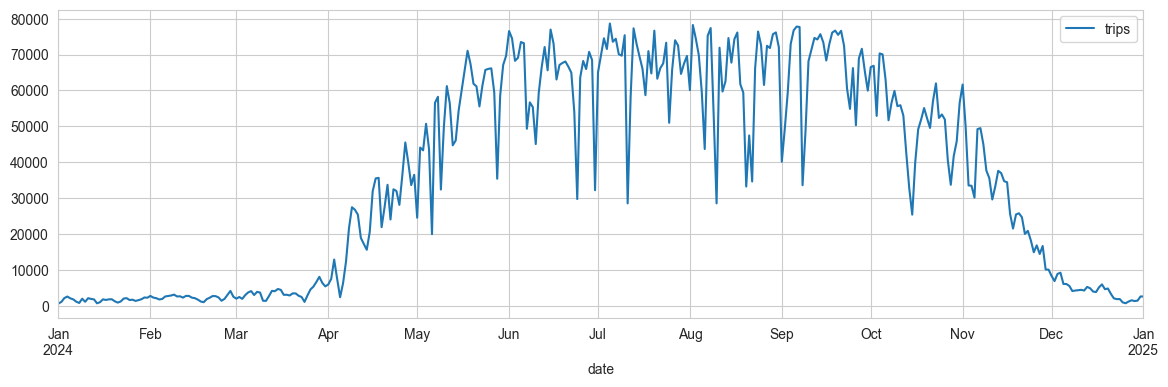

In [3]:
# Daily trip count
daily = duckdb.sql("""
    SELECT DATE(to_timestamp(start_time_ms/1000.0)) as date, COUNT(*) as trips
    FROM read_parquet("../../data/**/*.parquet")  
    GROUP BY date ORDER BY date
""").df()
daily.plot(x='date', y='trips', figsize=(14,4))

<Axes: xlabel='hour'>

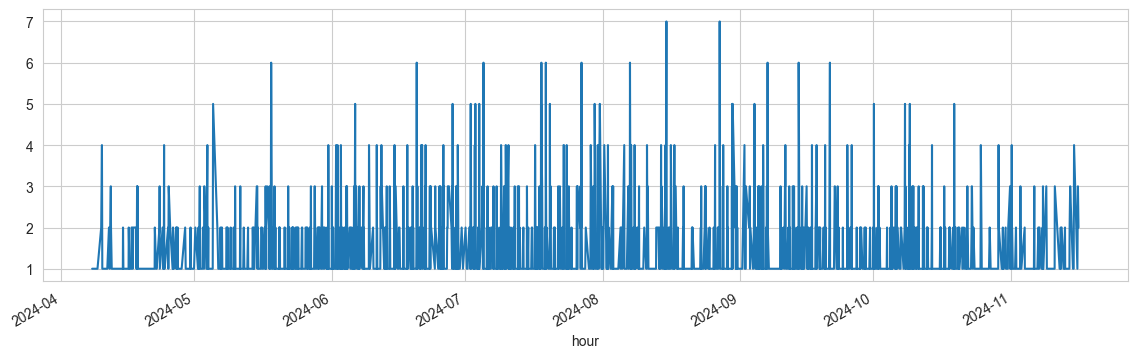

In [ ]:
# Hourly trips for station of name "Stinson / Montpellier"
station_17 = duckdb.sql("""
    SELECT DATE_TRUNC('hour', to_timestamp(start_time_ms/1000.0)) as hour,
           COUNT(*) as trips
    FROM read_parquet('../../data/**/*.parquet')
    WHERE start_station_name = 'Stinson / Montpellier'
    GROUP BY hour ORDER BY hour
""").df()
station_17.set_index('hour')['trips'].plot(figsize=(14,4))

## secondary analysis